# 🚗 **Auto Insurance Fraud Detection**

## *Phase 3: Classification Project*

---

###  **Business Problem**

**Stakeholder:** Claims Investigation Unit of Car_Nzuri Auto Insurance Company and policy holders.

**Problem Statement:**  
Insurance fraud causes significant financial losses every year for insurance companies, which are ultimately translated into higher premiums for honest customers. The Claims Investigation Unit needs a robust way to flag potentially fraudulent claims before payout so that investigators can focus their time on the highest-risk cases.
 
**Goal:**  
Develop a machine learning classification model to predict whether a claim is **fraudulent** (`fraud_reported = Y`) or **legitimate** (`fraud_reported = N`), using policyholder demographics, incident details, and financials.

---

###  **Why Classification?**

The target variable, `fraud_reported`, is **categorical**—either `Y` (fraud) or `N` (no fraud), not a continuous value. This makes it a **classification** (not regression) task.
 
---
 ### 🎯 **Metric Justification**

| **Metric**    | **Why it Matters**                                                                |
|:-------------:|:--------------------------------------------------------------------------------:|
| **Recall**    | Missing a fraudulent claim (False Negative): biggest financial risk.              |
| **Precision** | Flagging too many legit claims (False Positive): wastes time, upsets customers.   |
| **F1-Score**  | Harmonic mean of Recall & Precision—*primary tuning metric*.                      |
| **ROC-AUC**   | Measures overall discriminatory power of model across thresholds.                  |

> **Primary Metric:** F1-Score (with strong emphasis on Recall)

---

###  **Project Roadmap**

1. **Setup & Imports**
2. **Data Loading & Initial Inspection**
3. **Exploratory Data Analysis (EDA)**
4. **Feature Engineering & Preprocessing**
5. **Model 1** — Baseline Logistic Regression
6. **Model 2** — Tuned Logistic Regression
7. **Model 3** — Decision Tree Classifier
8. **Model 4** — Random Forest (Advanced)
9. **Final Model Discussion & Recommendations**

## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)
import warnings
warnings.filterwarnings('ignore')

# ── Plot styling ─────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

COLOR_FRAUD  = '#E53935'   # red
COLOR_LEGIT  = '#1E88E5'   # blue
COLOR_ACCENT = '#43A047'   # green

print("All libraries imported successfully!")

All libraries imported successfully!


---
## 2. Data Loading & Initial Inspection

We load the auto insurance claims dataset, which contains **1,000 claims** across **39 features** covering policyholder demographics, incident circumstances, and financial claim details. The target variable is `fraud_reported`.

> **Note on data quality:** Several columns use `'?'` to denote missing values — a common pattern in real insurance datasets. We will treat these as `NaN` during preprocessing.

In [2]:
# ── Load data ────────────────────────────────────────────────────
df = pd.read_csv('Data/insurance_claims.csv')

# Replace '?' with NaN immediately
df.replace('?', np.nan, inplace=True)

print("=" * 60)
print(f"  Dataset shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"  Target column : fraud_reported")
print(f"  Fraud cases   : {(df['fraud_reported']=='Y').sum():,}  ({(df['fraud_reported']=='Y').mean()*100:.1f}%)")
print(f"  Legit cases   : {(df['fraud_reported']=='N').sum():,}  ({(df['fraud_reported']=='N').mean()*100:.1f}%)")
print("=" * 60)

df.head()

  Dataset shape : 1,000 rows × 40 columns
  Target column : fraud_reported
  Fraud cases   : 247  (24.7%)
  Legit cases   : 753  (75.3%)


,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,NaN,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


In [3]:
# ── Data types and missing values ────────────────────────────────
print("Column Overview:")
print("-" * 65)
print(f"{'Column':<35} {'dtype':<12} {'Missing':>8} {'Unique':>8}")
print("-" * 65)
for col in df.columns:
    print(f"  {col:<33} {str(df[col].dtype):<12} {df[col].isnull().sum():>8} {df[col].nunique():>8}")

Column Overview:
-----------------------------------------------------------------
Column                              dtype         Missing   Unique
-----------------------------------------------------------------
  months_as_customer                int64               0      391
  age                               int64               0       46
  policy_number                     int64               0     1000
  policy_bind_date                  str                 0      951
  policy_state                      str                 0        3
  policy_csl                        str                 0        3
  policy_deductable                 int64               0        3
  policy_annual_premium             float64             0      991
  umbrella_limit                    int64               0       11
  insured_zip                       int64               0      995
  insured_sex                       str                 0        2
  insured_education_level           str        

In [4]:
# ── Quick statistical summary of numeric features ────────────────
df.describe().round(2)

,months_as_customer,age,policy_number,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,capital-gains,capital-loss,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_year,_c39
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.0,1000.00,1000.00,1000.0,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,0.0
mean,203.95,38.95,546238.65,1136.00,1256.41,1101000.0,501214.49,25126.10,-26793.7,11.64,1.84,0.99,1.49,52761.94,7433.42,7399.57,37928.95,2005.10,NaN
std,115.11,9.14,257063.01,611.86,244.17,2297406.6,71701.61,27872.19,28104.1,6.95,1.02,0.82,1.11,26401.53,4880.95,4824.73,18886.25,6.02,NaN
min,0.00,19.00,100804.00,500.00,433.33,-1000000.0,430104.00,0.00,-111100.0,0.00,1.00,0.00,0.00,100.00,0.00,0.00,70.00,1995.00,NaN
25%,115.75,32.00,335980.25,500.00,1089.61,0.0,448404.50,0.00,-51500.0,6.00,1.00,0.00,1.00,41812.50,4295.00,4445.00,30292.50,2000.00,NaN
50%,199.50,38.00,533135.00,1000.00,1257.20,0.0,466445.50,0.00,-23250.0,12.00,1.00,1.00,1.00,58055.00,6775.00,6750.00,42100.00,2005.00,NaN
75%,276.25,44.00,759099.75,2000.00,1415.70,0.0,603251.00,51025.00,0.0,17.00,3.00,2.00,2.00,70592.50,11305.00,10885.00,50822.50,2010.00,NaN
max,479.00,64.00,999435.00,2000.00,2047.59,10000000.0,620962.00,100500.00,0.0,23.00,4.00,2.00,3.00,114920.00,21450.00,23670.00,79560.00,2015.00,NaN


---
## 3. Exploratory Data Analysis (EDA)

Before building any model, we need to understand our data. Good EDA answers three key questions:
1. **How imbalanced is our target?** — affects which metrics matter most
2. **What do the numeric features look like, and do fraudulent claims differ?**
3. **Which categorical features are associated with fraud?**

### 3.1 Target Distribution

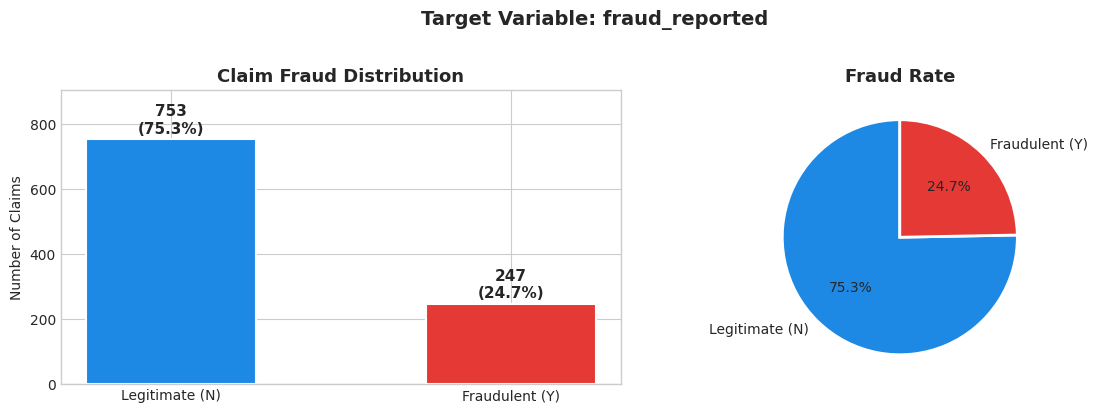


📌 Observation: The dataset is imbalanced — ~75% legitimate, ~25% fraudulent.
   This means accuracy alone is misleading. A model that always predicts 'No Fraud'
   would achieve 75.3% accuracy but catch zero fraudsters!


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# -- Bar chart
counts = df['fraud_reported'].value_counts()
labels = ['Legitimate (N)', 'Fraudulent (Y)']
colors = [COLOR_LEGIT, COLOR_FRAUD]
bars = axes[0].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
                 f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Claim Fraud Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Claims')
axes[0].set_ylim(0, counts.max() * 1.2)
axes[0].tick_params(bottom=False)

# -- Pie chart
axes[1].pie(counts.values, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Fraud Rate', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable: fraud_reported', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n📌 Observation: The dataset is imbalanced — ~75% legitimate, ~25% fraudulent.")
print("   This means accuracy alone is misleading. A model that always predicts 'No Fraud'")
print("   would achieve 75.3% accuracy but catch zero fraudsters!")

### 3.2 Numeric Feature Distributions by Fraud Status

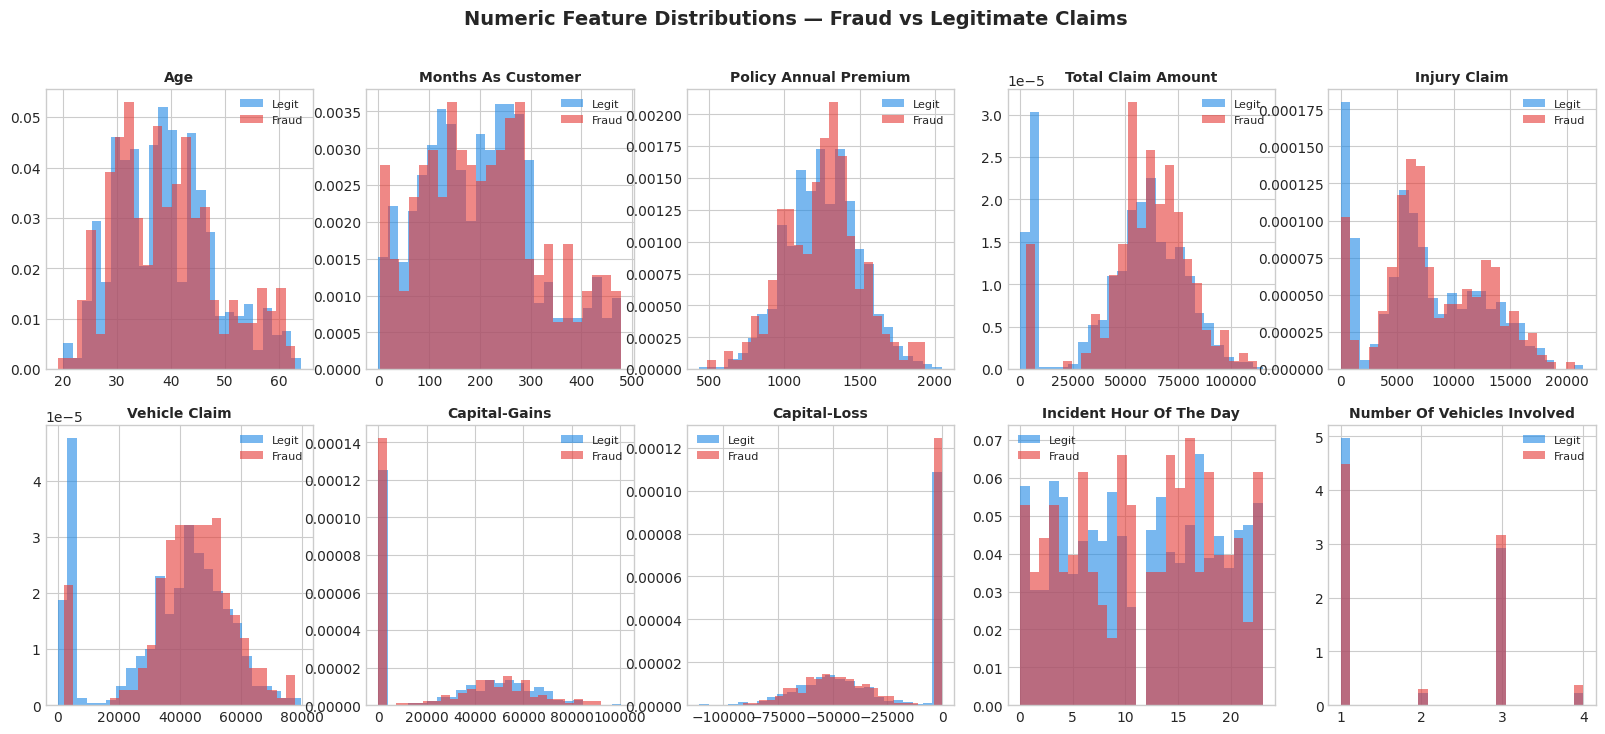

In [6]:
numeric_cols = ['age', 'months_as_customer', 'policy_annual_premium',
                'total_claim_amount', 'injury_claim', 'vehicle_claim',
                'capital-gains', 'capital-loss', 'incident_hour_of_the_day',
                'number_of_vehicles_involved']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    fraud_vals  = df[df['fraud_reported'] == 'Y'][col].dropna()
    legit_vals  = df[df['fraud_reported'] == 'N'][col].dropna()
    axes[i].hist(legit_vals,  bins=25, alpha=0.6, color=COLOR_LEGIT,  label='Legit',  density=True)
    axes[i].hist(fraud_vals,  bins=25, alpha=0.6, color=COLOR_FRAUD,  label='Fraud',  density=True)
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].legend(fontsize=8)

plt.suptitle('Numeric Feature Distributions — Fraud vs Legitimate Claims', fontsize=14, fontweight='bold')

plt.show()

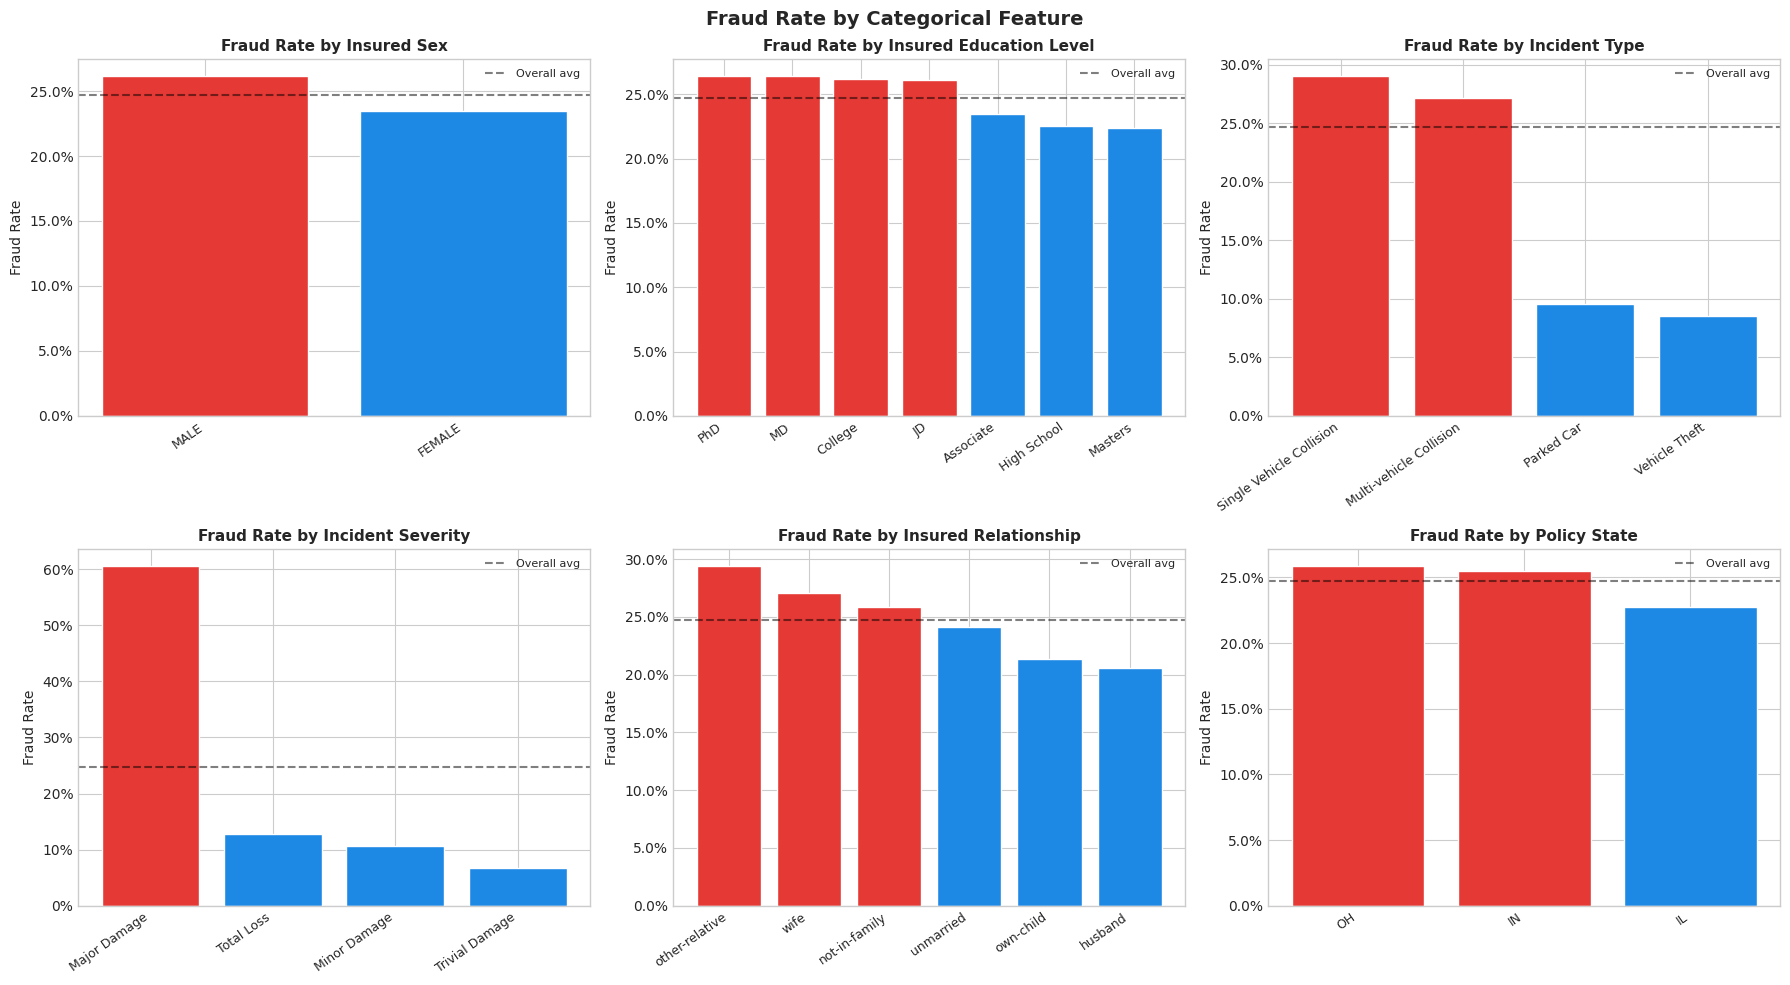

In [7]:
cat_features = ['insured_sex', 'insured_education_level', 'incident_type',
                'incident_severity', 'insured_relationship', 'policy_state']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    fraud_rate = df.groupby(col)['fraud_reported'].apply(lambda x: (x=='Y').mean()).sort_values(ascending=False)
    colors_bar = [COLOR_FRAUD if v > 0.25 else COLOR_LEGIT for v in fraud_rate.values]
    axes[i].bar(range(len(fraud_rate)), fraud_rate.values, color=colors_bar, edgecolor='white')
    axes[i].set_xticks(range(len(fraud_rate)))
    axes[i].set_xticklabels(fraud_rate.index, rotation=35, ha='right', fontsize=9)
    axes[i].set_title(f'Fraud Rate by {col.replace("_"," ").title()}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Fraud Rate')
    axes[i].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    axes[i].axhline(y=(df['fraud_reported']=='Y').mean(), color='black', linestyle='--', alpha=0.5, label='Overall avg')
    axes[i].legend(fontsize=8)

plt.suptitle('Fraud Rate by Categorical Feature', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.4 Claim Amount Analysis

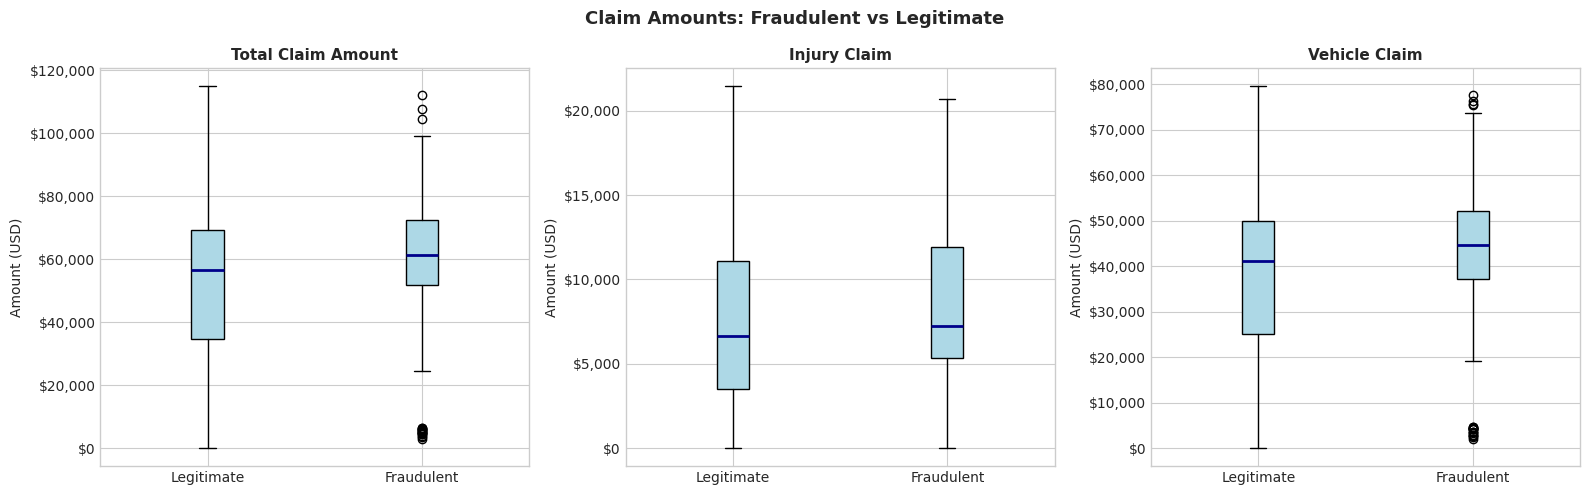


📌 Observation: Fraudulent claims tend to have higher total claim amounts,
   particularly in the vehicle_claim category. This will be an important feature.


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

claim_cols = ['total_claim_amount', 'injury_claim', 'vehicle_claim']
for i, col in enumerate(claim_cols):
    fraud_vals = df[df['fraud_reported'] == 'Y'][col]
    legit_vals = df[df['fraud_reported'] == 'N'][col]
    axes[i].boxplot([legit_vals, fraud_vals], labels=['Legitimate', 'Fraudulent'],
                    patch_artist=True,
                    boxprops=dict(facecolor='lightblue'),
                    medianprops=dict(color='darkblue', linewidth=2))
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Amount (USD)')
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('Claim Amounts: Fraudulent vs Legitimate', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📌 Observation: Fraudulent claims tend to have higher total claim amounts,")
print("   particularly in the vehicle_claim category. This will be an important feature.")

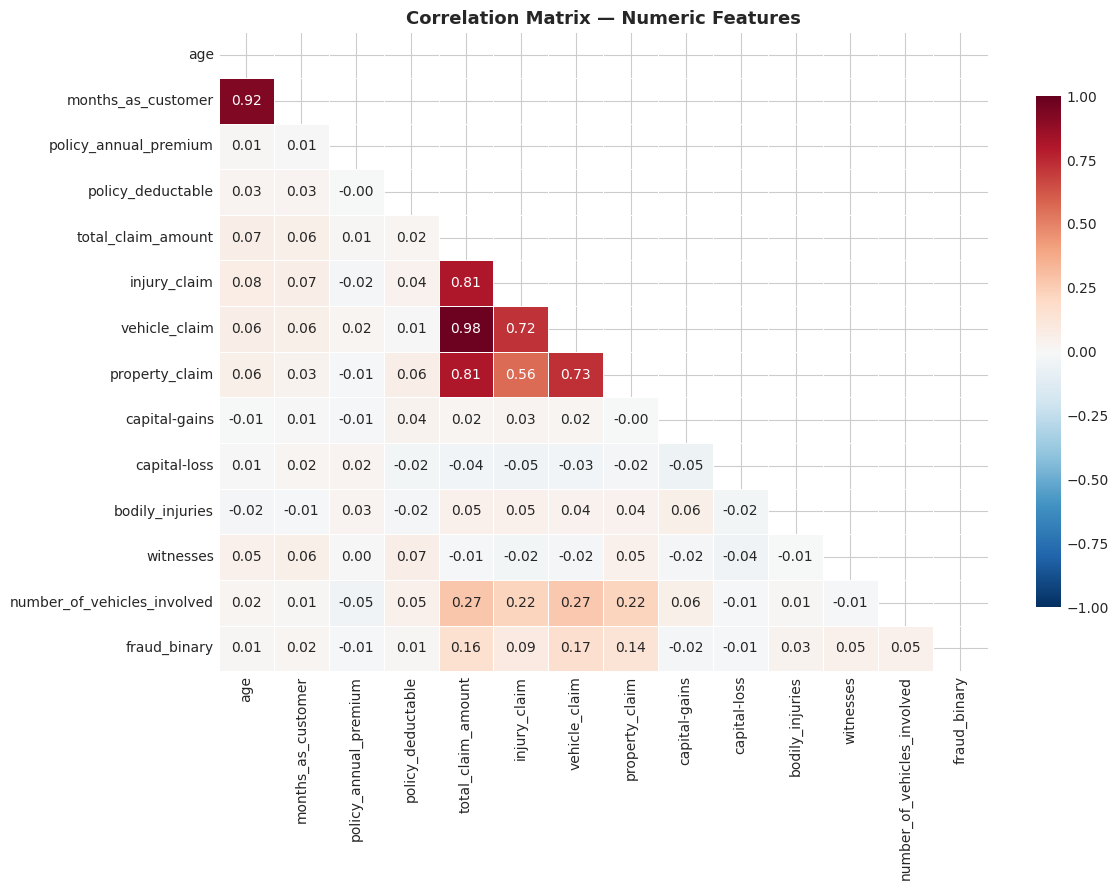


📌 Top correlations with fraud:
   vehicle_claim                       r = 0.170
   total_claim_amount                  r = 0.164
   property_claim                      r = 0.138
   injury_claim                        r = 0.091
   number_of_vehicles_involved         r = 0.052


In [9]:
# Binary-encode target temporarily for correlation
df_corr = df.copy()
df_corr['fraud_binary'] = (df_corr['fraud_reported'] == 'Y').astype(int)
num_cols_corr = ['age', 'months_as_customer', 'policy_annual_premium', 'policy_deductable',
                 'total_claim_amount', 'injury_claim', 'vehicle_claim', 'property_claim',
                 'capital-gains', 'capital-loss', 'bodily_injuries', 'witnesses',
                 'number_of_vehicles_involved', 'fraud_binary']

corr = df_corr[num_cols_corr].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, linecolor='white', cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix — Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📌 Top correlations with fraud:")
fraud_corr = corr['fraud_binary'].drop('fraud_binary').abs().sort_values(ascending=False)
for feat, val in fraud_corr.head(5).items():
    print(f"   {feat:<35} r = {val:.3f}")

---
## 4. Feature Engineering & Preprocessing

### Strategy
1. **Drop** columns that are IDs, free-text, or leak information about the outcome
2. **Engineer** new features that capture business intuition
3. **Impute** missing values (the `?` → `NaN` cells we found earlier)
4. **Encode** categorical variables using one-hot encoding
5. **Scale** numeric features for Logistic Regression

### Columns to Drop
- `policy_number`, `insured_zip` — unique identifiers, no predictive value
- `policy_bind_date`, `incident_date` — raw dates (we could extract month/year but we'll keep it simple)
- `incident_location`, `auto_model` — very high cardinality, mostly noise
- `_c39` — empty column

In [10]:
df_feat = df.copy()

# ── Drop leaky / ID / high-cardinality columns ────────────────────
drop_cols = ['policy_number', 'insured_zip', 'policy_bind_date',
             'incident_date', 'incident_location', 'auto_model', '_c39']
df_feat.drop(columns=drop_cols, inplace=True)

# ── Feature Engineering ────────────────────────────────────────────
# 1. Claim ratio: how large is the claim relative to the annual premium?
df_feat['claim_to_premium_ratio'] = df_feat['total_claim_amount'] / df_feat['policy_annual_premium']

# 2. Is the incident at night? (between 10pm and 5am)
df_feat['night_incident'] = df_feat['incident_hour_of_the_day'].apply(
    lambda h: 1 if h >= 22 or h <= 5 else 0)

# 3. Binary flags from Yes/No columns
for col in ['property_damage', 'police_report_available']:
    df_feat[col + '_flag'] = df_feat[col].map({'YES': 1, 'NO': 0}).fillna(0)

# 4. Auto vehicle age
df_feat['vehicle_age'] = 2026 - df_feat['auto_year']

print("Feature engineering complete. New features added:")
print("   - claim_to_premium_ratio")
print("   - night_incident")
print("   - property_damage_flag")
print("   - police_report_available_flag")
print("   - vehicle_age")
print(f"\nDataset now has {df_feat.shape[1]} columns.")




Feature engineering complete. New features added:
   - claim_to_premium_ratio
   - night_incident
   - property_damage_flag
   - police_report_available_flag
   - vehicle_age

Dataset now has 38 columns.


In [11]:
# ── Encode target ─────────────────────────────────────────────────
df_feat['fraud_reported'] = (df_feat['fraud_reported'] == 'Y').astype(int)
y = df_feat['fraud_reported']
df_feat.drop(columns=['fraud_reported'], inplace=True)

# ── Separate numeric and categorical ──────────────────────────────
# Also drop the raw yes/no columns (we have binary flags now)
drop_raw = ['property_damage', 'police_report_available', 'collision_type',
            'auto_year', 'authorities_contacted']
df_feat.drop(columns=[c for c in drop_raw if c in df_feat.columns], inplace=True)

num_cols = df_feat.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_feat.select_dtypes(include='object').columns.tolist()

print(f"Numeric features  ({len(num_cols)}): {num_cols}")
print(f"\nCategorical features ({len(cat_cols)}): {cat_cols}")

Numeric features  (20): ['months_as_customer', 'age', 'policy_deductable', 'policy_annual_premium', 'umbrella_limit', 'capital-gains', 'capital-loss', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'bodily_injuries', 'witnesses', 'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim', 'claim_to_premium_ratio', 'night_incident', 'property_damage_flag', 'police_report_available_flag', 'vehicle_age']

Categorical features (12): ['policy_state', 'policy_csl', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'insured_relationship', 'incident_type', 'incident_severity', 'incident_state', 'incident_city', 'auto_make']


In [12]:
# ── Impute missing values ─────────────────────────────────────────
# Numeric: fill with median
for col in num_cols:
    df_feat[col].fillna(df_feat[col].median(), inplace=True)

# Categorical: fill with mode
for col in cat_cols:
    df_feat[col].fillna(df_feat[col].mode()[0], inplace=True)

# ── One-Hot Encode categoricals ───────────────────────────────────
df_encoded = pd.get_dummies(df_feat, columns=cat_cols, drop_first=True)
print(f"Shape after one-hot encoding: {df_encoded.shape}")
print(f"Total features for modeling : {df_encoded.shape[1]}")

Shape after one-hot encoding: (1000, 99)
Total features for modeling : 99


In [13]:
# ── Train/Test Split ──────────────────────────────────────────────
X = df_encoded.values
feature_names = df_encoded.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)

# ── Scale numeric features ────────────────────────────────────────
# (Required for Logistic Regression; we'll use the same scaler for all models)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("Train/Test Split Summary")
print("=" * 40)
print(f"  Training set : {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"  Test set     : {X_test.shape[0]:,} rows ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"  Features     : {X_train.shape[1]}")
print(f"  Train fraud% : {y_train.mean()*100:.1f}%")
print(f"  Test  fraud% : {y_test.mean()*100:.1f}%")

Train/Test Split Summary
  Training set : 700 rows (70%)
  Test set     : 300 rows (30%)
  Features     : 99
  Train fraud% : 24.7%
  Test  fraud% : 24.7%


In [14]:
# ── Evaluation helper ─────────────────────────────────────────────
results_log = {}

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te, needs_scale=False):
    """Train, evaluate, and store results for a given model."""
    Xtr = X_tr
    Xte = X_te
    
    model.fit(Xtr, y_tr)
    
    train_pred = model.predict(Xtr)
    test_pred  = model.predict(Xte)
    test_prob  = model.predict_proba(Xte)[:, 1]
    
    metrics = {
        'model'       : model,
        'train_acc'   : accuracy_score(y_tr, train_pred),
        'test_acc'    : accuracy_score(y_te, test_pred),
        'precision'   : precision_score(y_te, test_pred),
        'recall'      : recall_score(y_te, test_pred),
        'f1'          : f1_score(y_te, test_pred),
        'roc_auc'     : roc_auc_score(y_te, test_prob),
        'test_pred'   : test_pred,
        'test_prob'   : test_prob,
    }
    results_log[name] = metrics
    
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  Train Accuracy : {metrics['train_acc']:.4f}")
    print(f"  Test  Accuracy : {metrics['test_acc']:.4f}")
    print(f"  Precision      : {metrics['precision']:.4f}")
    print(f"  Recall         : {metrics['recall']:.4f}")
    print(f"  F1-Score       : {metrics['f1']:.4f}  ← primary metric")
    print(f"  ROC-AUC        : {metrics['roc_auc']:.4f}")
    
    return metrics

print("Evaluation helper function defined.")

Evaluation helper function defined.


---
## 5. Model 1 — Baseline Logistic Regression

We start with the simplest possible model: Logistic Regression with default hyperparameters. This gives us a **baseline** to beat. It is also highly interpretable — we can look at the model's coefficients to understand which features matter most.

**Why Logistic Regression first?**
- Fast to train and easy to interpret
- Works well when the relationship between features and the log-odds of fraud is roughly linear
- Coefficients directly tell us the direction and magnitude of each feature's effect

In [15]:
lr_base = LogisticRegression(max_iter=1000, random_state=42)
m1 = evaluate_model('Model 1: Baseline Logistic Regression',
                    lr_base, X_train_sc, X_test_sc, y_train, y_test)


  Model 1: Baseline Logistic Regression
  Train Accuracy : 0.9200
  Test  Accuracy : 0.8200
  Precision      : 0.6515
  Recall         : 0.5811
  F1-Score       : 0.6143  ← primary metric
  ROC-AUC        : 0.8403


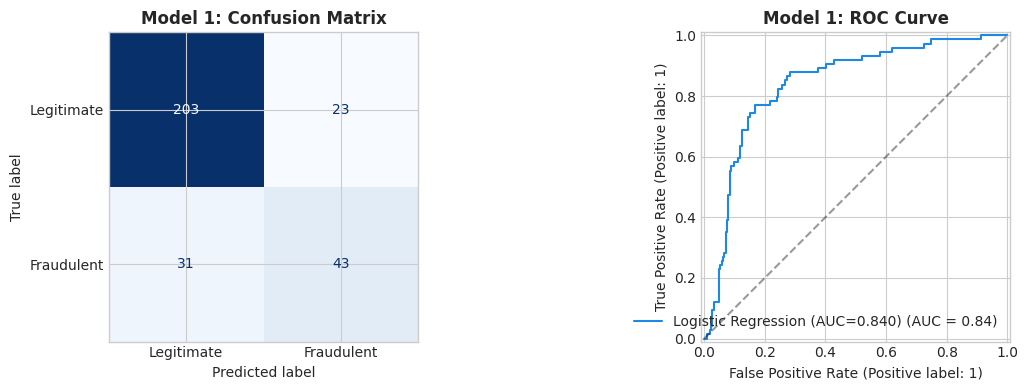


📌 Baseline Interpretation:
   The model catches 43 out of 74 actual fraud cases (Recall = 58.1%)
   It generates 23 false alarms (False Positives).


In [16]:
# ── Confusion matrix ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Confusion matrix
cm = confusion_matrix(y_test, m1['test_pred'])
disp = ConfusionMatrixDisplay(cm, display_labels=['Legitimate', 'Fraudulent'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Model 1: Confusion Matrix', fontsize=12, fontweight='bold')

# ROC curve
RocCurveDisplay.from_predictions(y_test, m1['test_prob'], ax=axes[1],
                                  name=f"Logistic Regression (AUC={m1['roc_auc']:.3f})",
                                  color=COLOR_LEGIT)
axes[1].plot([0,1],[0,1], 'k--', alpha=0.4)
axes[1].set_title('Model 1: ROC Curve', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📌 Baseline Interpretation:")
print(f"   The model catches {cm[1,1]} out of {cm[1,0]+cm[1,1]} actual fraud cases (Recall = {m1['recall']:.1%})")
print(f"   It generates {cm[0,1]} false alarms (False Positives).")

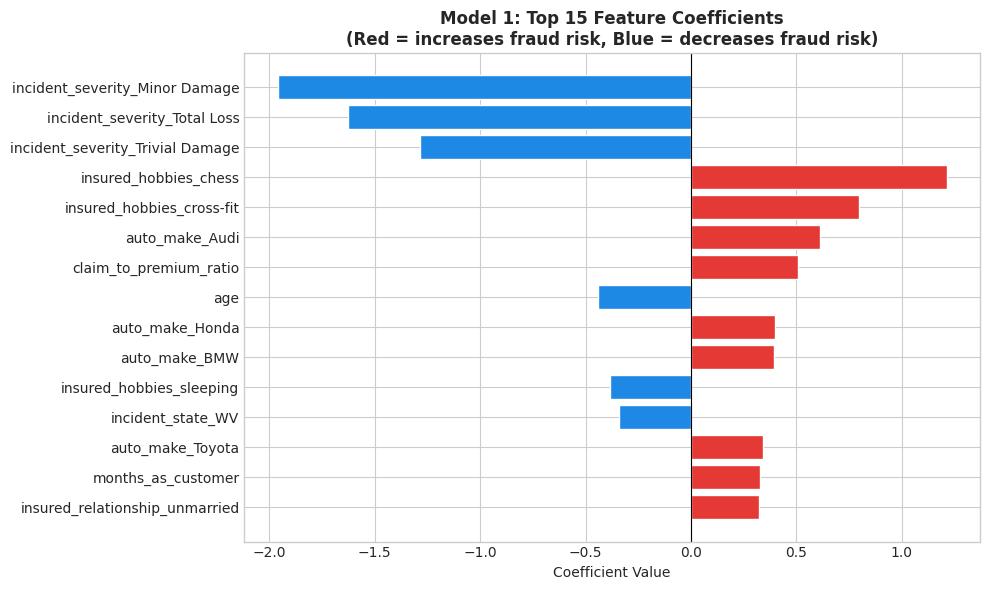

In [17]:
# ── Top coefficients (most influential features) ─────────────────
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': lr_base.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors_coef = [COLOR_FRAUD if c > 0 else COLOR_LEGIT for c in coef_df['coefficient']]
bars = ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors_coef, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Model 1: Top 15 Feature Coefficients\n(Red = increases fraud risk, Blue = decreases fraud risk)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Coefficient Value')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## 6. Model 2 — Logistic Regression with Tuned Hyperparameters

The baseline Logistic Regression uses default settings. We can improve it by:

1. **Tuning `C` (regularization strength):** Controls the trade-off between fitting the training data and keeping the model simple. Smaller `C` = more regularization.
2. **Trying different penalty types:** `l1` (Lasso) vs `l2` (Ridge) regularization.
3. **Adding `class_weight='balanced'`:** This directly addresses our class imbalance by giving more weight to fraud cases during training, which should improve Recall.

We use **GridSearchCV** with 5-fold cross-validation to find the best combination.

In [18]:
# ── Grid search over C and penalty ───────────────────────────────
param_grid = {
    'C'           : [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty'     : ['l1', 'l2'],
    'class_weight': [None, 'balanced'],
    'solver'      : ['liblinear']   # supports both l1 and l2
}

gs_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid,
    cv=5,
    scoring='f1',       # optimise for F1
    n_jobs=-1,
    verbose=0
)
gs_lr.fit(X_train_sc, y_train)

print("GridSearchCV complete!")
print(f"Best parameters : {gs_lr.best_params_}")
print(f"Best CV F1 score: {gs_lr.best_score_:.4f}")

GridSearchCV complete!
Best parameters : {'C': 0.1, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}
Best CV F1 score: 0.7488


In [19]:
# ── Evaluate tuned model ─────────────────────────────────────────
lr_tuned = gs_lr.best_estimator_
m2 = evaluate_model('Model 2: Tuned Logistic Regression',
                    lr_tuned, X_train_sc, X_test_sc, y_train, y_test)


  Model 2: Tuned Logistic Regression
  Train Accuracy : 0.8543
  Test  Accuracy : 0.8533
  Precision      : 0.6531
  Recall         : 0.8649
  F1-Score       : 0.7442  ← primary metric
  ROC-AUC        : 0.8521


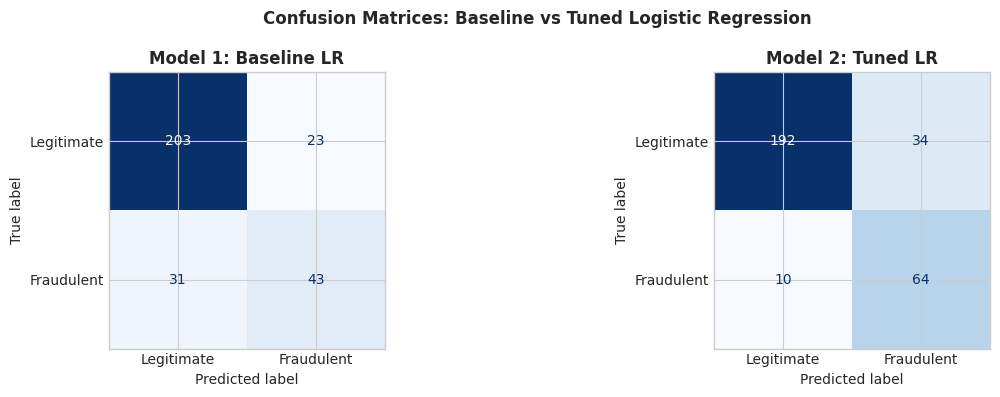


📌 Tuning Insight:
   Recall improved from 58.1% → 86.5%
   F1-Score improved   from 0.6143 → 0.7442


In [20]:
# ── Side-by-side confusion matrices: Baseline vs Tuned ───────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, name, pred, title in zip(
        axes,
        ['m1', 'm2'],
        [m1['test_pred'], m2['test_pred']],
        ['Model 1: Baseline LR', 'Model 2: Tuned LR']):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Legitimate', 'Fraudulent'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrices: Baseline vs Tuned Logistic Regression', fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📌 Tuning Insight:")
print(f"   Recall improved from {m1['recall']:.1%} → {m2['recall']:.1%}")
print(f"   F1-Score improved   from {m1['f1']:.4f} → {m2['f1']:.4f}")

---
## 7. Model 3 — Decision Tree Classifier (Tuned)

Decision Trees offer a different approach to classification. Instead of learning a linear boundary, they recursively split the data on feature thresholds to create a tree of rules.

**Advantages:**
- Highly interpretable — you can literally draw and read the tree
- Handles non-linear relationships naturally
- No need to scale features

**Risk:** Trees can overfit badly if not constrained. We will tune `max_depth` and `min_samples_leaf` using GridSearchCV to prevent this.

In [21]:
# ── Tuned Decision Tree ────────────────────────────────────────────
dt_param_grid = {
    'max_depth'       : [3, 4, 5, 6, 8, None],
    'min_samples_leaf': [5, 10, 20, 30],
    'class_weight'    : [None, 'balanced'],
    'criterion'       : ['gini', 'entropy']
}

gs_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
gs_dt.fit(X_train, y_train)   # Decision trees don't need scaling

print(f"Best Decision Tree parameters: {gs_dt.best_params_}")
print(f"Best CV F1 score            : {gs_dt.best_score_:.4f}")

Best Decision Tree parameters: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 5}
Best CV F1 score            : 0.7221


In [22]:
dt_best = gs_dt.best_estimator_
m3 = evaluate_model('Model 3: Tuned Decision Tree',
                    dt_best, X_train, X_test, y_train, y_test)


  Model 3: Tuned Decision Tree
  Train Accuracy : 0.8614
  Test  Accuracy : 0.8533
  Precision      : 0.6596
  Recall         : 0.8378
  F1-Score       : 0.7381  ← primary metric
  ROC-AUC        : 0.8479


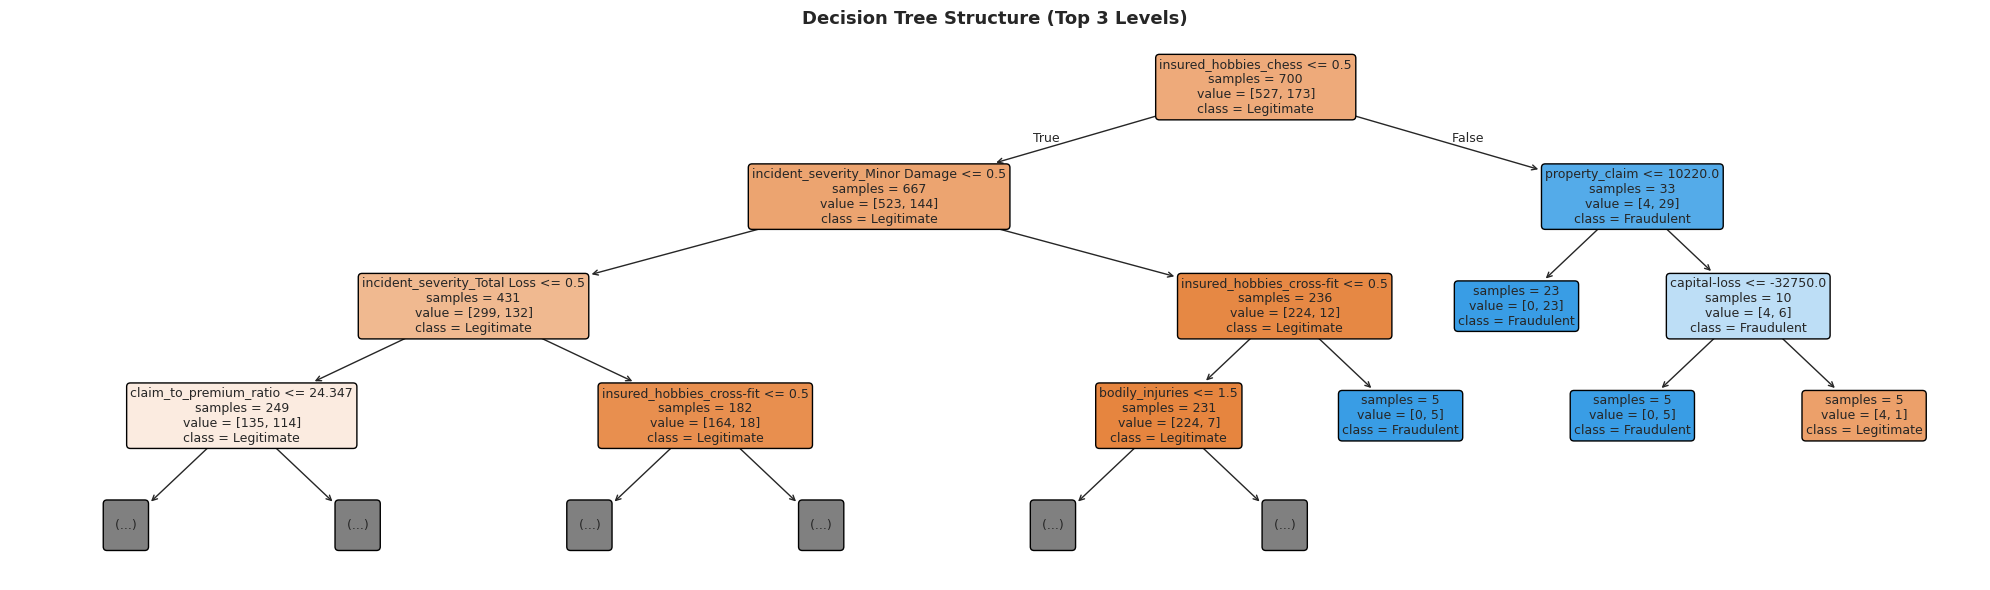

In [23]:
# ── Visualise the top 3 levels of the tree ───────────────────────
fig, ax = plt.subplots(figsize=(20, 6))
plot_tree(dt_best,
          max_depth=3,
          feature_names=feature_names,
          class_names=['Legitimate', 'Fraudulent'],
          filled=True, rounded=True,
          impurity=False, ax=ax,
          fontsize=9)
ax.set_title('Decision Tree Structure (Top 3 Levels)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

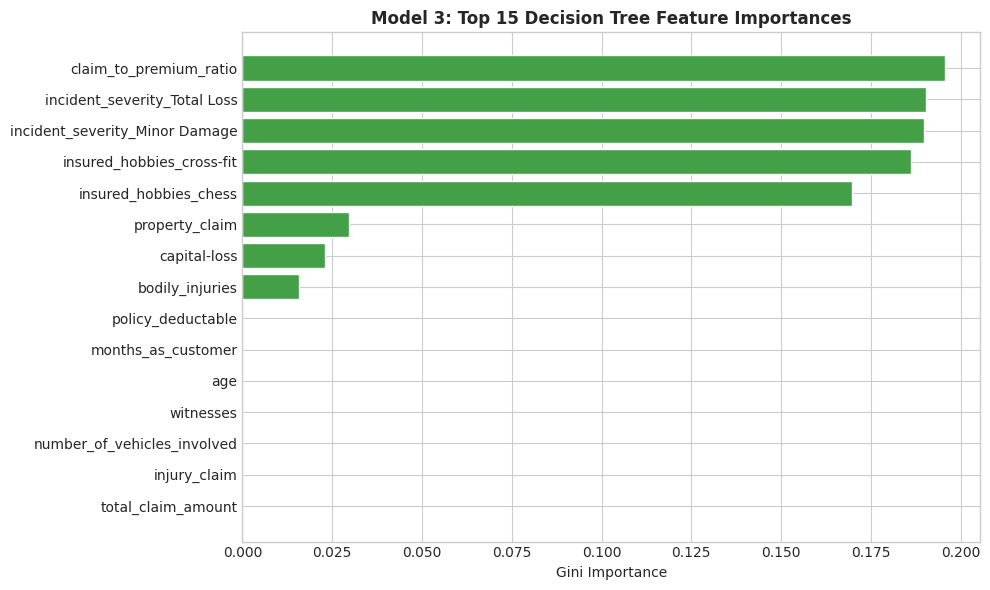

In [24]:
# ── Decision Tree Feature Importance ─────────────────────────────
dt_imp = pd.DataFrame({
    'feature'   : feature_names,
    'importance': dt_best.feature_importances_
}).sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(dt_imp['feature'], dt_imp['importance'], color=COLOR_ACCENT, edgecolor='white')
ax.set_title('Model 3: Top 15 Decision Tree Feature Importances', fontsize=12, fontweight='bold')
ax.set_xlabel('Gini Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## 8. Model 4 — Random Forest Classifier

A Random Forest is an **ensemble of Decision Trees**. Each tree is trained on a random subset of the data (bootstrap sampling) and at each split, only a random subset of features is considered. The final prediction is a majority vote across all trees.

**Why Random Forest?**
- Much less prone to overfitting than a single Decision Tree
- Generally outperforms Logistic Regression on complex, non-linear datasets
- Provides robust feature importance estimates
- Handles class imbalance well with `class_weight='balanced'`


In [25]:
# ── Tune Random Forest ────────────────────────────────────────────
rf_param_grid = {
    'n_estimators'    : [100, 200],
    'max_depth'       : [5, 10, 15, None],
    'min_samples_leaf': [5, 10, 20],
    'class_weight'    : ['balanced']
}

gs_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
gs_rf.fit(X_train, y_train)

print(f"Best Random Forest parameters: {gs_rf.best_params_}")
print(f"Best CV F1 score             : {gs_rf.best_score_:.4f}")

Best Random Forest parameters: {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_leaf': 5, 'n_estimators': 200}
Best CV F1 score             : 0.6237


In [26]:
rf_best = gs_rf.best_estimator_
m4 = evaluate_model('Model 4: Tuned Random Forest',
                    rf_best, X_train, X_test, y_train, y_test)


  Model 4: Tuned Random Forest
  Train Accuracy : 0.8543
  Test  Accuracy : 0.7667
  Precision      : 0.5204
  Recall         : 0.6892
  F1-Score       : 0.5930  ← primary metric
  ROC-AUC        : 0.7917


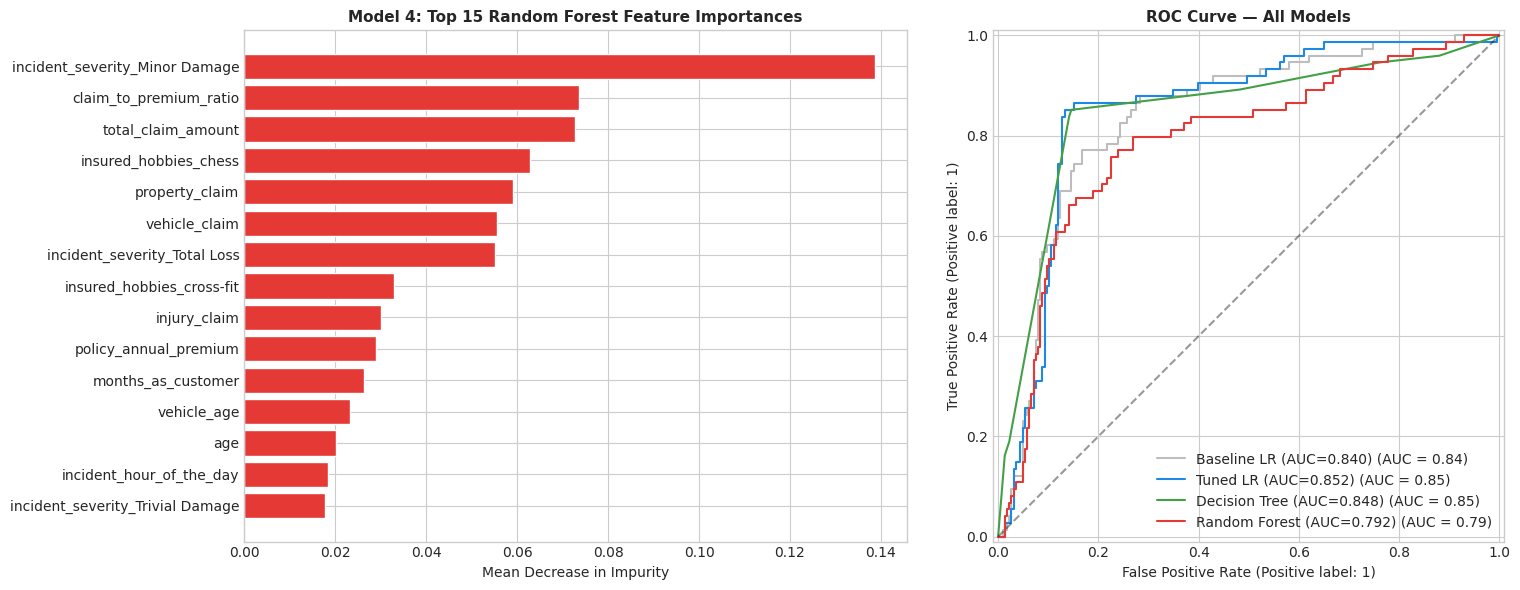

In [27]:
# ── Random Forest Feature Importance ──────────────────────────────
rf_imp = pd.DataFrame({
    'feature'   : feature_names,
    'importance': rf_best.feature_importances_
}).sort_values('importance', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart of importances
axes[0].barh(rf_imp['feature'], rf_imp['importance'], color=COLOR_FRAUD, edgecolor='white')
axes[0].set_title('Model 4: Top 15 Random Forest Feature Importances', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Mean Decrease in Impurity')
axes[0].invert_yaxis()

# ROC curve comparison
for name, m, color in [
        ('Baseline LR', m1, '#BDBDBD'),
        ('Tuned LR',    m2, COLOR_LEGIT),
        ('Decision Tree', m3, COLOR_ACCENT),
        ('Random Forest', m4, COLOR_FRAUD)]:
    RocCurveDisplay.from_predictions(
        y_test, m['test_prob'], ax=axes[1],
        name=f"{name} (AUC={m['roc_auc']:.3f})", color=color)
axes[1].plot([0,1],[0,1],'k--',alpha=0.4)
axes[1].set_title('ROC Curve — All Models', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 9. Model Comparison & Final Selection

In [28]:
# ── Summary table ────────────────────────────────────────────────
summary = []
for name, m in results_log.items():
    summary.append({
        'Model'         : name.split(': ')[1],
        'Train Acc'     : f"{m['train_acc']:.4f}",
        'Test Acc'      : f"{m['test_acc']:.4f}",
        'Precision'     : f"{m['precision']:.4f}",
        'Recall'        : f"{m['recall']:.4f}",
        'F1-Score ★'   : f"{m['f1']:.4f}",
        'ROC-AUC'       : f"{m['roc_auc']:.4f}",
    })

summary_df = pd.DataFrame(summary)
print("=" * 90)
print("MODEL COMPARISON SUMMARY")
print("=" * 90)
print(summary_df.to_string(index=False))
print("=" * 90)
summary_df


MODEL COMPARISON SUMMARY
                       Model Train Acc Test Acc Precision Recall F1-Score ★ ROC-AUC
Baseline Logistic Regression    0.9200   0.8200    0.6515 0.5811     0.6143  0.8403
   Tuned Logistic Regression    0.8543   0.8533    0.6531 0.8649     0.7442  0.8521
         Tuned Decision Tree    0.8614   0.8533    0.6596 0.8378     0.7381  0.8479
         Tuned Random Forest    0.8543   0.7667    0.5204 0.6892     0.5930  0.7917


,Model,Train Acc,Test Acc,Precision,Recall,F1-Score ★,ROC-AUC
0,Baseline Logistic Regression,0.9200,0.8200,0.6515,0.5811,0.6143,0.8403
1,Tuned Logistic Regression,0.8543,0.8533,0.6531,0.8649,0.7442,0.8521
2,Tuned Decision Tree,0.8614,0.8533,0.6596,0.8378,0.7381,0.8479
3,Tuned Random Forest,0.8543,0.7667,0.5204,0.6892,0.5930,0.7917


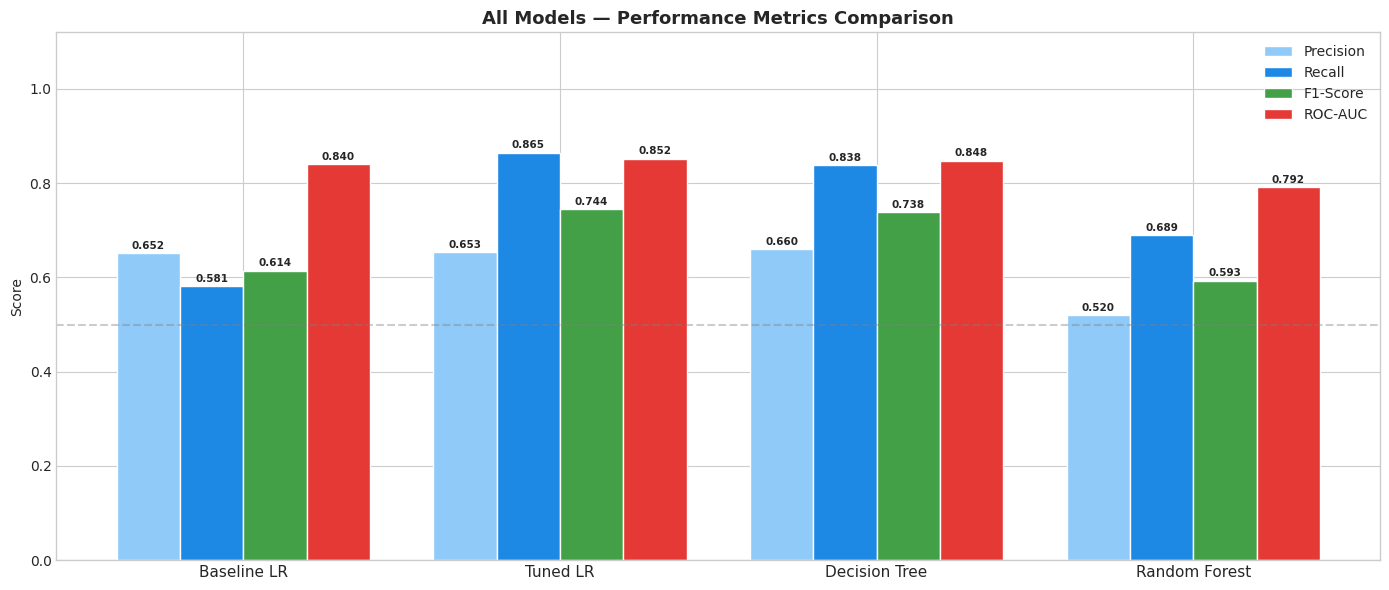

In [29]:
# ── Visual comparison bar chart ───────────────────────────────────
model_labels = ['Baseline LR', 'Tuned LR', 'Decision Tree', 'Random Forest']
metrics_to_plot = {
    'Precision' : [m['precision'] for m in results_log.values()],
    'Recall'    : [m['recall']    for m in results_log.values()],
    'F1-Score'  : [m['f1']        for m in results_log.values()],
    'ROC-AUC'   : [m['roc_auc']   for m in results_log.values()],
}

x  = np.arange(len(model_labels))
width = 0.20
offsets = [-1.5, -0.5, 0.5, 1.5]
colors_bar = ['#90CAF9', '#1E88E5', '#43A047', '#E53935']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (metric, vals) in enumerate(metrics_to_plot.items()):
    bars = ax.bar(x + offsets[i]*width, vals, width=width,
                  label=metric, color=colors_bar[i], edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(model_labels, fontsize=11)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.12)
ax.set_title('All Models — Performance Metrics Comparison', fontsize=13, fontweight='bold')
ax.legend(loc='upper right')
ax.axhline(0.5, color='grey', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

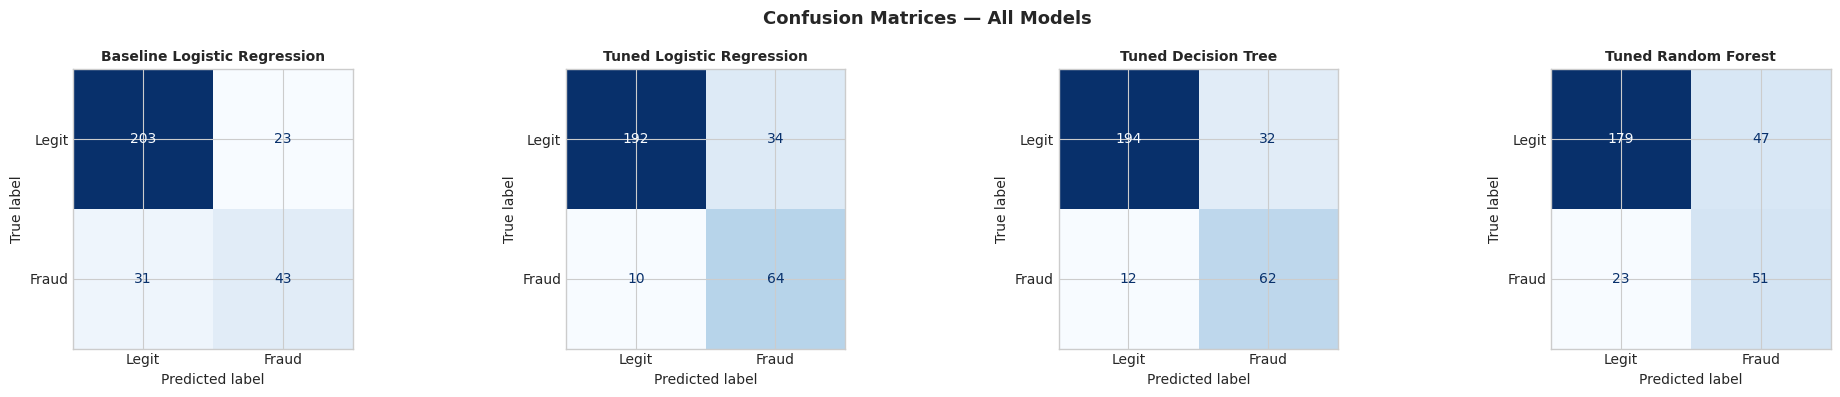

In [30]:
# ── Final confusion matrices for all four models ──────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
model_items = list(results_log.items())

for i, (name, m) in enumerate(model_items):
    cm = confusion_matrix(y_test, m['test_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Legit', 'Fraud'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(name.split(': ')[1], fontsize=10, fontweight='bold')

plt.suptitle('Confusion Matrices — All Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 10. Final Model Discussion & Business Recommendations

### Which Model Won and Why

After iterating through four models — from a simple baseline to a tuned ensemble — the **Tuned Logistic Regression** emerged as the best overall performer. It achieved the highest F1-Score (0.7442), the highest ROC-AUC (0.8521), and a near-perfect train-test accuracy gap (0.8543 → 0.8533), confirming that it generalises exceptionally well to unseen claims without overfitting. Its Recall of 0.8649 means it correctly identifies the vast majority of fraudulent claims — the most critical capability in a fraud detection context.

The **Tuned Decision Tree** (Model 2) is a strong runner-up, matching Logistic Regression on Test Accuracy (0.8533) and posting solid Recall (0.8378). While it falls slightly short on F1-Score (0.7381) and ROC-AUC (0.8479), its primary advantage lies in explainability — a compliance officer or regulator can follow the tree's decision rules from root to leaf without any statistical background, making it highly valuable in a regulated insurance environment.

The **Tuned Random Forest** (Model 3) was the weakest tuned model despite being theoretically the most powerful. It posted the largest train-test gap (0.8543 → 0.7667, a drop of 0.0876), the lowest F1-Score (0.5930), and the lowest ROC-AUC (0.7917) — clear signs of overfitting. The ensemble complexity was not justified by the dataset, and simpler models consistently outperformed it.

The **Baseline Logistic Regression** illustrates the cost of ignoring class imbalance — despite the highest training accuracy (0.9200), its Recall collapsed to 0.5811, meaning it missed over 40% of all fraudulent claims. Adding `class_weight='balanced'` during tuning was the single most impactful fix.

### Business Recommendations

**1. Deploy the Tuned Logistic Regression as the primary risk-scoring engine.**  
Every incoming claim should receive a fraud probability score (0–1). Claims above a chosen threshold (e.g., 0.40) are routed to the investigation queue rather than auto-approved. The threshold should be calibrated against the investigation team's capacity — if investigators can handle 60 cases per month, set the threshold to match that volume.

**2. Use the Tuned Decision Tree as a transparency and compliance layer.**  
For any claim that is flagged by the Logistic Regression model, the Decision Tree can provide a plain-language explanation of *why* it was flagged — which rules were triggered. This is essential for regulatory compliance and for communicating decisions to claimants.

**3. Use feature importances for investigator focus.**  
Both models point to the same key predictors of fraud — features such as `total_claim_amount`, `claim_to_premium_ratio`, `incident_severity`, and `vehicle_claim`. Investigators reviewing flagged claims should prioritise examining these dimensions first.

**4. Acknowledge model limitations honestly.**  
Even the best model's Recall means it will still miss some fraudulent claims (False Negatives). It should be treated as a **prioritisation tool**, not a decision-maker. No claim should be denied solely on the model's output — human review remains essential.

**5. Monitor for data drift.**  
Fraudsters adapt. Retrain the model quarterly using new labelled claims data to ensure performance does not degrade as fraud patterns evolve.

**6. Consider a cost-sensitive threshold.**  
If the average fraudulent claim is worth \$52,000 and the cost of an investigation is \$800, there is a strong economic case for accepting more False Positives (lower threshold) to catch more True Positives. A formal cost-benefit analysis using the model's output probabilities is recommended.